# 신용카드 고객 이탈 예측 프로젝트
##  회귀 모델링
데이터: `bankchurners_clean.csv`
## 참고: 생존분석(예상 이탈시점 예측)을 시도했으나 적용하지 못한 이유

원래는 , **예상 이탈시점**을 예측하려 시도했습니다. `Months_on_book`(카드 보유 개월수)을 duration으로, `Target`을 event로 설정해 생존분석을 적용.

**결과: 이 데이터는 생존분석에 구조적으로 부적합함을 확인.**

- 이탈(1) 그룹의 평균 보유기간: **36.2개월**
- 유지(0) 그룹의 평균 보유기간: **35.9개월**

두 그룹의 보유기간 분포가 거의 동일. 즉, 이 데이터에서는 "얼마나 오래 카드를 썼는지"가 이탈 여부·시점과 거의 관련이 없음.

이는 코드나 파라미터의 문제가 아니라, **이 Kaggle 데이터셋이 애초에 한 시점의 스냅샷 데이터로 설계되어, `Months_on_book`이 실제 "이탈까지 남은 시간"을 반영하도록 만들어지지 않았기 때문**.  
시간 흐름이 있는 로그 데이터(예: 일별/월별 이용 기록)가 있어야 의미 있는 생존분석이 가능.

따라서 이번 회귀 단계에서는 예상 이탈시점 대신, **예상 거래건수**을 타겟으로 하는 단순 회귀로 대체해 진행.

## 0. 라이브러리 & 데이터 로드

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

df = pd.read_csv("../data/processed/bankchurners_clean.csv")
df.shape

(10127, 20)

In [29]:
df.columns

Index(['Customer_Age', 'Gender', 'Dependent_count', 'Education_Level',
       'Marital_Status', 'Income_Category', 'Card_Category', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio',
       'Target'],
      dtype='str')

## 1. 타겟 설정
타겟: `Total_Trans_Ct` (최근 12개월 총 거래건수)

제외 컬럼: `Target`(분류 타겟), `Total_Ct_Chng_Q4_Q1`(거래건수 변화율 — 데이터 누수 위험)

In [30]:
X = df.drop(columns=["Total_Trans_Ct", "Target", "Total_Ct_Chng_Q4_Q1"])
y = df["Total_Trans_Ct"]

cat_cols = X.select_dtypes(include="object").columns.tolist()
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

print("X shape:", X.shape)
print("y 요약통계:")
y.describe()

X shape: (10127, 30)
y 요약통계:


C:\Users\UK\AppData\Local\Temp\ipykernel_29584\907866147.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include="object").columns.tolist()


count    10127.000000
mean        64.858695
std         23.472570
min         10.000000
25%         45.000000
50%         67.000000
75%         81.000000
max        139.000000
Name: Total_Trans_Ct, dtype: float64

## 2. Train/Test 분할

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (8101, 30) Test: (2026, 30)


## 3. — 선형회귀
StandardScaler 적용

In [32]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lin = lr.predict(X_test_scaled)

## 4. — Random Forest Regressor

In [33]:
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

## 5. — XGBRegressor

In [34]:
xgb = XGBRegressor(n_estimators=200, random_state=42)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

## 6. 모델 성능 비교 (MAE, RMSE, R²)

In [35]:
def evaluate_reg(name, y_train_true, y_train_pred, y_test_true, y_test_pred):
    return {
        "Model": name,
        "Train_R2": r2_score(y_train_true, y_train_pred),
        "Test_R2": r2_score(y_test_true, y_test_pred),
        "MAE": mean_absolute_error(y_test_true, y_test_pred),
        "RMSE": mean_squared_error(y_test_true, y_test_pred) ** 0.5,
    }

# 각 모델의 train 예측값도 함께 계산
y_train_pred_lin = lr.predict(X_train_scaled)
y_train_pred_rf = rf.predict(X_train)
y_train_pred_xgb = xgb.predict(X_train)

results = pd.DataFrame([
    evaluate_reg("Linear Regression", y_train, y_train_pred_lin, y_test, y_pred_lin),
    evaluate_reg("Random Forest Regressor", y_train, y_train_pred_rf, y_test, y_pred_rf),
    evaluate_reg("XGBoost Regressor", y_train, y_train_pred_xgb, y_test, y_pred_xgb),
])

results.set_index("Model").round(3)

,Train_R2,Test_R2,MAE,RMSE
Model,,,,
Linear Regression,0.679,0.667,10.988,13.350
Random Forest Regressor,0.982,0.856,6.983,8.787
XGBoost Regressor,0.985,0.831,7.512,9.502


## 7. 실제값 vs 예측값 산점도
대각선(y=x)에 가까울수록 예측이 정확한 것입니다.

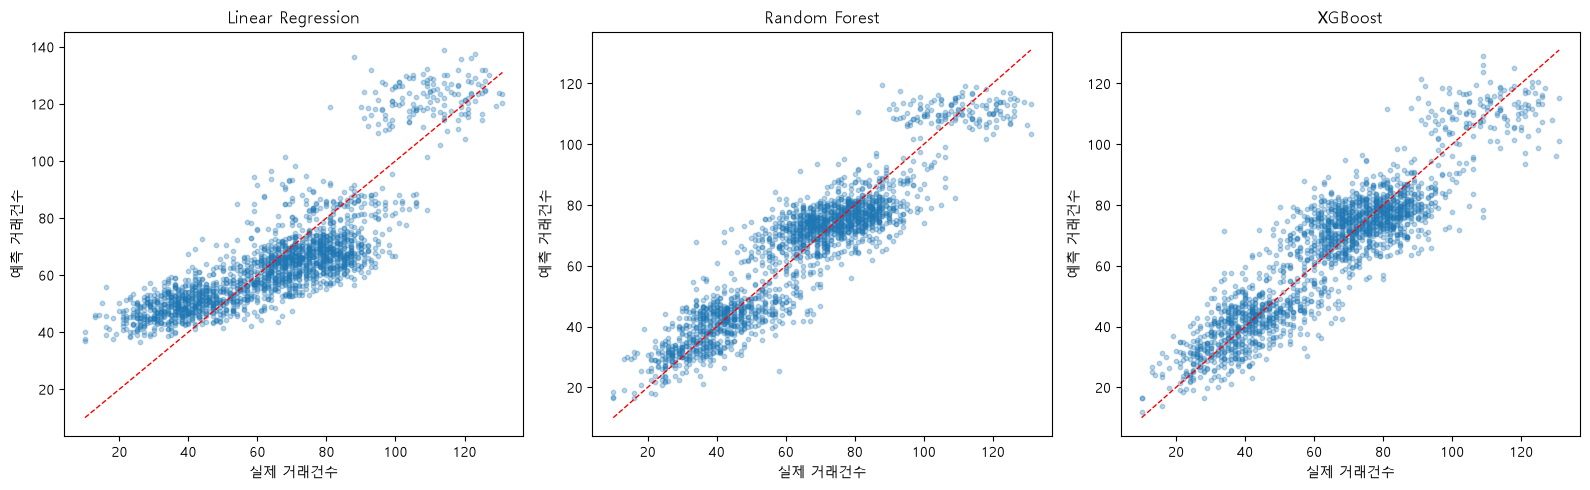

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, y_pred) in zip(
    axes, [("Linear Regression", y_pred_lin),
           ("Random Forest", y_pred_rf),
           ("XGBoost", y_pred_xgb)]
):
    ax.scatter(y_test, y_pred, alpha=0.3, s=10)
    lims = [y_test.min(), y_test.max()]
    ax.plot(lims, lims, color="red", linestyle="--", linewidth=1)
    ax.set_title(name)
    ax.set_xlabel("실제 거래건수")
    ax.set_ylabel("예측 거래건수")

plt.tight_layout()
plt.show()

## 8. 기본 Feature Importance (XGBoost 기준)

In [37]:
importance = pd.Series(xgb.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(10)

Total_Trans_Amt                 0.652174
Marital_Status_Married          0.027787
Total_Amt_Chng_Q4_Q1            0.017207
Marital_Status_Single           0.016874
Card_Category_Silver            0.015511
Total_Revolving_Bal             0.015453
Total_Relationship_Count        0.014274
Income_Category_$80K - $120K    0.013949
Marital_Status_Unknown          0.012883
Avg_Open_To_Buy                 0.012877
dtype: float32

## 9. 비즈니스 적용 — '예상 활동수준 대비 실제 활동' 격차 기반 조기경보

이 회귀 모델은 "이 고객의 프로필로 미뤄봤을 때 정상적으로 나와야 할 거래건수"를 추정합니다.

**활동성 갭 = 실제 거래건수 - 예측 거래건수**

갭이 큰 음수(-)일수록 "이 고객은 원래 이 정도 써야 하는데 갑자기 덜 쓰고 있다"는 신호이며,
분류 모델의 이탈확률이 계산되기 전 단계에서도 활용 가능한 조기경보 지표입니다.

(아래는 Random Forest(`rf`) 예측 기준입니다.)

In [38]:
gap_df = pd.DataFrame({
    "고객ID": X_test.index,
    "실제_거래건수": y_test.values,
    "예측_거래건수": y_pred_rf,
})
gap_df["활동성_갭"] = gap_df["실제_거래건수"] - gap_df["예측_거래건수"]

gap_df["실제_이탈여부"] = df.loc[X_test.index, "Target"].values

gap_df

,고객ID,실제_거래건수,예측_거래건수,활동성_갭,실제_이탈여부
0,3781,64,67.890,-3.890,0
1,2922,79,73.905,5.095,0
2,5070,67,76.515,-9.515,0
3,7246,74,79.920,-5.920,0
4,623,35,34.970,0.030,0
...,...,...,...,...,...
2021,1937,69,64.465,4.535,0
2022,4705,42,53.220,-11.220,1
2023,8548,75,82.210,-7.210,0
2024,1346,36,48.795,-12.795,0


## 10. 조기경보 대상: 활동성 갭이 가장 큰(음수) 고객 Top 15

In [39]:
early_warning = gap_df.sort_values("활동성_갭").head(15)
early_warning

,고객ID,실제_거래건수,예측_거래건수,활동성_갭,실제_이탈여부
377,4999,34,67.700,-33.700,1
244,10099,88,119.530,-31.530,0
382,9326,81,110.530,-29.530,0
930,9172,42,71.140,-29.140,1
1112,9240,44,71.990,-27.990,1
1990,9375,57,84.280,-27.280,1
823,9612,64,91.125,-27.125,1
732,9149,42,67.675,-25.675,1
950,4681,48,72.940,-24.940,0
220,9995,93,117.570,-24.570,0


## 11. 검증: 활동성 갭이 실제 이탈과 관련 있는가?
갭을 5개 구간으로 나눠, 구간별 실제 이탈률을 비교합니다.

갭 구간별 실제 이탈률(%):
갭_구간
1_매우낮음(예측대비 급감)    20.7
2_낮음               17.5
3_보통               21.2
4_높음               14.3
5_매우높음(예측대비 초과)     6.9
Name: 실제_이탈여부, dtype: float64


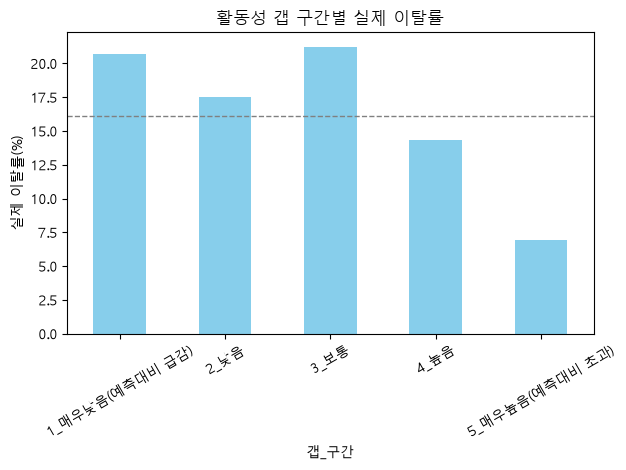

In [40]:
gap_df["갭_구간"] = pd.qcut(
    gap_df["활동성_갭"], q=5,
    labels=["1_매우낮음(예측대비 급감)", "2_낮음", "3_보통", "4_높음", "5_매우높음(예측대비 초과)"]
)

churn_rate_by_gap = gap_df.groupby("갭_구간", observed=True)["실제_이탈여부"].mean() * 100
print("갭 구간별 실제 이탈률(%):")
print(churn_rate_by_gap.round(1))

churn_rate_by_gap.plot(kind="bar", color="skyblue", rot=30)
plt.ylabel("실제 이탈률(%)")
plt.title("활동성 갭 구간별 실제 이탈률")
plt.axhline(gap_df["실제_이탈여부"].mean()*100, color="gray", linestyle="--", linewidth=1)
plt.tight_layout()
plt.show()

In [ ]:
# 구간별 표본 수 확인 (혹시 표본이 너무 작아서 흔들리는 건 아닌지)
print("구간별 표본 수:")
print(gap_df["갭_구간"].value_counts())

# 연속값 기준 상관계수
corr = gap_df["활동성_갭"].corr(gap_df["실제_이탈여부"])
print(f"\n활동성 갭과 이탈여부의 상관계수: {corr:.3f}")

# 0에 가까울수록 = 관련 없음
# -1에 가까울수록 = "갭이 작을수록(활동 급감) 이탈할 확률이 높다"는 관계가 강함
# +1에 가까울수록 = 반대 관계

구간별 표본 수:
갭_구간
1_매우낮음(예측대비 급감)    406
2_낮음               405
3_보통               405
4_높음               405
5_매우높음(예측대비 초과)    405
Name: count, dtype: int64

활동성 갭과 이탈여부의 상관계수: -0.130


In [42]:
# 로지스틱 회귀로 활동성 갭 하나만 넣고 계수 유의성(방향성) 확인
from sklearn.linear_model import LogisticRegression

lr_check = LogisticRegression()
lr_check.fit(gap_df[["활동성_갭"]], gap_df["실제_이탈여부"])
print("활동성 갭의 로지스틱 회귀 계수:", lr_check.coef_[0][0])
print("(음수면 갭이 작을수록<활동 급감> 이탈 확률이 높아지는 전반적 추세가 있다는 뜻)")

활동성 갭의 로지스틱 회귀 계수: -0.040821087196061166
(음수면 갭이 작을수록<활동 급감> 이탈 확률이 높아지는 전반적 추세가 있다는 뜻)


## 정리
- '활동성 갭' 구간별 실제 이탈률을 비교해, 예측보다 활동이 급감한 구간과 초과한 구간의   
  이탈률 차이를 확인 

- 실무 적용: 매달 이 갭을 재계산해, 상위 급감 고객에게 분류모델의 이탈확률 계산을 기다리지 않고   
  **선제적으로 활성화 캠페인**(포인트 2배, 사용 유도 알림 등)을 발송할 수 있음.

- 5개 구간(qcut)으로 나눴을 때는 '3구간(보통)'이 오히려 높게 나오는 등 계단식 패턴이 깨졌지만,  
  이는 표본 크기(구간당 약 400명)에 따른 노이즈

- 연속값 기준 상관계수와 로지스틱 회귀 계수의 방향(음수)이 일관되게 나온다면,  
  '활동성 갭이 작을수록(활동 급감) 이탈 위험이 높아진다'는 전반적인 추세 자체는  
  존재   
  다만 이 관계가 깨끗한 선형은 아니므로, 실무 적용 시에는  
  극단적으로 갭이 작은 고객군(예: 하위 10%)을 우선 스크리닝하는 방식이 더 안전

### 이 지표 하나만으로 이탈을 완벽하게 예측할 수는 없지만, 완전히 쓸모없는 지표도 아님.

    이탈 시점을 예측할순 없었지만 거래건수를 예측한 모델 자체는 유효  
    이를 활용해 "가입 후 일정 기간이 지난 고객의 정상 활동 범위 벤치마크"를 제시하거나,
    기존 고객의 "예상 대비 활동 급감" 조기경보 지표로 활용하는 것이 더 적합함.